In [4]:
import ale_py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.callbacks import BaseCallback
import os, json
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecEnvWrapper
from stable_baselines3.common.atari_wrappers import AtariWrapper
 
gym.register_envs(ale_py)
print("Imports OK")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Imports OK


Reward Shaping Wrapper

In [5]:
class RewardShapingWrapper(gym.Wrapper):
    def __init__(self, env, survival_bonus=0.0, death_penalty=0.0,
                 power_pellet_bonus=0.0):
        super().__init__(env)
        self.survival_bonus     = survival_bonus
        self.death_penalty      = death_penalty
        self.power_pellet_bonus = power_pellet_bonus
        self._prev_lives = None  # set on first step, not reset
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None  # clear so first step re-initialises it
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
 
        shaped_reward = reward 
 
        # Initialise lives tracker 
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Survival bonus
        if not terminated:
            shaped_reward += self.survival_bonus
 
        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty  # value is negative
 
        self._prev_lives = current_lives
 
        # Power pellet bonus
        if reward == 50:
            shaped_reward += self.power_pellet_bonus
 
        return obs, shaped_reward, terminated, truncated, info

Define the 4 Experimental Conditions

In [6]:
CONDITIONS = {
    "Baseline": {
        "survival_bonus":     0.0,
        "death_penalty":      0.0,
        "power_pellet_bonus": 0.0,
        "color": "#4C9BE8",
        "description": "Default ALE rewards only"
    },
    "Survival Bonus": {
        "survival_bonus":     0.01,   # +0.01 every step alive
        "death_penalty":      0.0,
        "power_pellet_bonus": 0.0,
        "color": "#57C97A",
        "description": "+0.01 per step survived"
    },
    "Death Penalty": {
        "survival_bonus":     0.0,
        "death_penalty":     -50.0,   # -50 on each death
        "power_pellet_bonus": 0.0,
        "color": "#E8604C",
        "description": "-50 on each life lost"
    },
    "Dense Shaping": {
        "survival_bonus":     0.01,   # survival bonus
        "death_penalty":     -50.0,   # death penalty
        "power_pellet_bonus": 10.0,   # bonus for eating power pellet
        "color": "#C97AE8",
        "description": "Survival + Death penalty + Power pellet bonus"
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:20s} — {cfg['description']}")

Conditions defined:
  Baseline             — Default ALE rewards only
  Survival Bonus       — +0.01 per step survived
  Death Penalty        — -50 on each life lost
  Dense Shaping        — Survival + Death penalty + Power pellet bonus


Progress Callback (tracks metrics per episode)

In [ ]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose=0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []
        self.episode_lengths = []
        self._current_reward = 0
        self._current_length = 0
 
    def _on_step(self):
        self._current_reward += self.locals["rewards"][0]
        self._current_length += 1
 
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self.episode_lengths.append(self._current_length)
            self._current_reward = 0
            self._current_length = 0
            if len(self.episode_rewards) % 50 == 0:
                recent_r = np.mean(self.episode_rewards[-20:])
                recent_l = np.mean(self.episode_lengths[-20:])
                print(f"  [{self.condition_name}] "
                      f"Ep {len(self.episode_rewards):>4} | "
                      f"Steps {self.num_timesteps:>7,} | "
                      f"Avg reward: {recent_r:>7.1f} | "
                      f"Avg length: {recent_l:>5.0f}")
        return True
 

Training Function

In [8]:
def make_env(condition_name, condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5")
        env = RewardShapingWrapper(
            env,
            survival_bonus=condition_cfg["survival_bonus"],
            death_penalty=condition_cfg["death_penalty"],
            power_pellet_bonus=condition_cfg["power_pellet_bonus"],
        )
        return env
    return _init
 
 
def train_condition(condition_name, condition_cfg,
                    total_timesteps=1_000_000, seed=42):
    print(f"\n{'='*60}")
    print(f"Training: {condition_name}")
    print(f"Config:   {condition_cfg['description']}")
    print(f"{'='*60}")

    def make_env_fn():
        env = gym.make("ALE/MsPacman-v5")
        env = RewardShapingWrapper(
            env,
            survival_bonus=condition_cfg["survival_bonus"],
            death_penalty=condition_cfg["death_penalty"],
            power_pellet_bonus=condition_cfg["power_pellet_bonus"],
        )
        env = AtariWrapper(env, clip_reward=False)
        return env

    vec_env = DummyVecEnv([make_env_fn])
    vec_env = VecFrameStack(vec_env, n_stack=4)

    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps=128,
        batch_size=256,
        n_epochs=4,
        gamma=0.99,
        learning_rate=2.5e-4,
        clip_range=0.1,
        verbose=0,
        seed=seed,
    )

    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)

    save_path = f"model_{condition_name.replace(' ', '_').lower()}"
    model.save(save_path)
    print(f"  Saved to {save_path}.zip")

    vec_env.close()
    return model, callback

In [9]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.6.0+cu124
True


Run All 4 Training Conditions

In [10]:
TOTAL_STEPS = 10000
 
results = {} 
 
for name, cfg in CONDITIONS.items():
    model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS)
    results[name] = {
        "callback": callback,
        "model": model,
        "episode_rewards": callback.episode_rewards,
        "episode_lengths": callback.episode_lengths,
    }
 
print("\nAll conditions trained!")


Training: Baseline
Config:   Default ALE rewards only


g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Baseline] Ep   50 | Steps   2,442 | Avg reward:   199.0 | Avg length:    57
  [Baseline] Ep  100 | Steps   5,198 | Avg reward:   136.0 | Avg length:    54
  [Baseline] Ep  150 | Steps   7,854 | Avg reward:   131.5 | Avg length:    50
  Saved to model_baseline.zip

Training: Survival Bonus
Config:   +0.01 per step survived


g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Survival Bonus] Ep   50 | Steps   2,150 | Avg reward:   188.0 | Avg length:    51
  [Survival Bonus] Ep  100 | Steps   4,455 | Avg reward:    75.2 | Avg length:    42
  [Survival Bonus] Ep  150 | Steps   6,553 | Avg reward:   140.2 | Avg length:    43
  [Survival Bonus] Ep  200 | Steps   8,983 | Avg reward:   137.5 | Avg length:    50
  Saved to model_survival_bonus.zip

Training: Death Penalty
Config:   -50 on each life lost
  [Death Penalty] Ep   50 | Steps   2,136 | Avg reward:    81.5 | Avg length:    42
  [Death Penalty] Ep  100 | Steps   4,684 | Avg reward:    92.0 | Avg length:    51
  [Death Penalty] Ep  150 | Steps   7,147 | Avg reward:    77.0 | Avg length:    52
  [Death Penalty] Ep  200 | Steps   9,702 | Avg reward:   101.5 | Avg length:    53
  Saved to model_death_penalty.zip

Training: Dense Shaping
Config:   Survival + Death penalty + Power pellet bonus
  [Dense Shaping] Ep   50 | Steps   1,905 | Avg reward:   107.2 | Avg length:    43
  [Dense Shaping] Ep  100 | Ste

Evaluation Function (epsilon=0, real game rewards)

In [11]:
def evaluate_agent(model, condition_cfg, n_episodes=100, seed=99):
    def make_env_fn():
        env = gym.make("ALE/MsPacman-v5")
        env = RewardShapingWrapper(
            env,
            survival_bonus=condition_cfg["survival_bonus"],
            death_penalty=condition_cfg["death_penalty"],
            power_pellet_bonus=condition_cfg["power_pellet_bonus"],
        )
        env = AtariWrapper(env, clip_reward=False)
        return env

    eval_env = DummyVecEnv([make_env_fn])
    eval_env = VecFrameStack(eval_env, n_stack=4)

    scores, lengths = [], []
    for ep in range(n_episodes):
        obs = eval_env.reset()
        total_reward, length, done = 0, 0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = eval_env.step(action)
            total_reward += reward[0]
            length += 1                           
        scores.append(total_reward)
        lengths.append(length)                     
    eval_env.close()
    return np.array(scores), np.array(lengths)

Evaluate All Conditions

In [12]:
eval_results = {}
 
for name, data in results.items():
    print(f"Evaluating {name}...")
    scores, lengths = evaluate_agent(data["model"], CONDITIONS[name], n_episodes=100)
    eval_results[name] = {"scores": scores, "lengths": lengths}
    print(f"  Avg score:  {scores.mean():.1f} ± {scores.std():.1f}")
    print(f"  Avg length: {lengths.mean():.1f}")

Evaluating Baseline...
  Avg score:  23.8 ± 33.2
  Avg length: 41.6
Evaluating Survival Bonus...
  Avg score:  21.8 ± 28.6
  Avg length: 36.3
Evaluating Death Penalty...
  Avg score:  -29.6 ± 28.4
  Avg length: 36.3
Evaluating Dense Shaping...
  Avg score:  16.3 ± 90.6
  Avg length: 41.8


Learning Curves (all 4 on one graph)

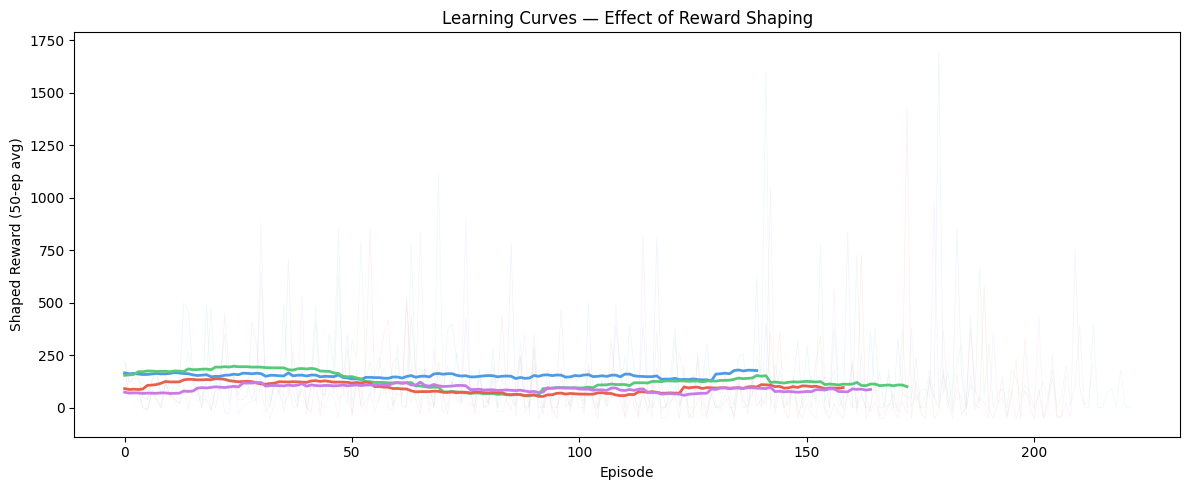

In [ ]:
def smooth(arr, window=50):
    if len(arr) < window:
        return np.array(arr)
    return np.convolve(arr, np.ones(window)/window, mode='valid')
 
fig, ax = plt.subplots(figsize=(12, 5))
 
for name, data in results.items():
    cfg = CONDITIONS[name]
    rewards = data["episode_rewards"]
    smoothed = smooth(rewards, window=50)
    episodes = np.arange(len(smoothed))
 
    ax.plot(episodes, smoothed,
            color=cfg["color"], linewidth=2, label=name)
    # faint raw line
    ax.plot(np.arange(len(rewards)), rewards,
            color=cfg["color"], alpha=0.1, linewidth=0.5)
 
ax.set_xlabel("Episode")
ax.set_ylabel("Shaped Reward (50-ep avg)")
ax.set_title("Learning Curves — Effect of Reward Shaping")
plt.tight_layout()
plt.savefig("plot_learning_curves.png")
plt.show()

Score Distribution (box plot)

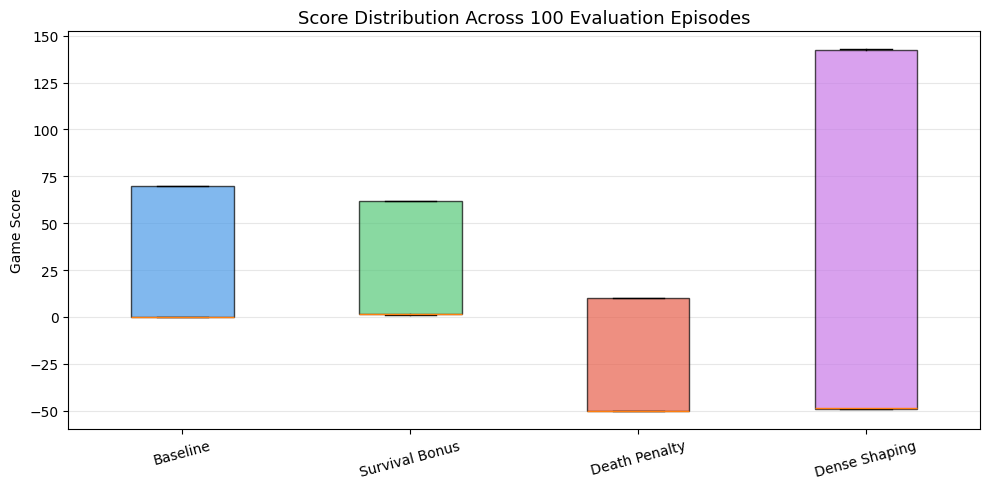

Saved plot_score_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
 
data_to_plot = [eval_results[n]["scores"] for n in names]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False)
 
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
 
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Game Score")
ax.set_title("Score Distribution Across 100 Evaluation Episodes", fontsize=13)
plt.tight_layout()
plt.savefig("plot_score_distribution.png", dpi=130)
plt.show()
print("Saved plot_score_distribution.png")

Summary Table

In [19]:
print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print(f"{'Condition':<20} {'Avg Score':>10} {'Std':>8} "
      f"{'Avg Length':>12} {'Max Score':>10}")
print("-"*70)
 
for name in names:
    s = eval_results[name]["scores"]
    l = eval_results[name]["lengths"]
    print(f"{name:<20} {s.mean():>10.1f} {s.std():>8.1f} "
          f"{l.mean():>12.1f} {s.max():>10.0f}")
 
print("="*70)


EXPERIMENT SUMMARY
Condition             Avg Score      Std   Avg Length  Max Score
----------------------------------------------------------------------
Baseline                   23.8     33.2         41.6         70
Survival Bonus             21.8     28.6         36.3         62
Death Penalty             -29.6     28.4         36.3         10
Dense Shaping              16.3     90.6         41.8        143
